In [1]:
%loadlibs

Loaded libraries:
	- numpy (np)
	- matplotlib.pyplot (plt)
	- torch
	- torch.nn (nn)
	- torch.optim (optim)
	- tqdm


In [2]:
torch.set_default_dtype(torch.float32)

In [55]:
k = 8
p = nn.Parameter(torch.tensor([1. for _ in range(k)]))

In [70]:
def f(x):
    powers = torch.arange(1, k+1)
    x_expanded = x.unsqueeze(-1)
    numerator_terms = p * x_expanded**(2 * powers)
    numerator = torch.sum(numerator_terms, dim=-1)
    denominator = (1 + x**2)**k
    return numerator / denominator

In [57]:
print(f(torch.ones((1, 10))))

tensor([[0.0312, 0.0312, 0.0312, 0.0312, 0.0312, 0.0312, 0.0312, 0.0312, 0.0312,
         0.0312]], grad_fn=<DivBackward0>)


In [58]:
epochs = 10000
optimizer = optim.Adam([p], lr=100.)

$\text{loss} = f^{(4)} - |f|^8 * f$

In [59]:
def nth_derivative(f, x, n):
    for i in range(n):
        x = x.clone().detach().requires_grad_(True)
        y = f(x)
        grads = torch.autograd.grad(
            outputs=y,
            inputs=x,
            grad_outputs=torch.ones_like(y),
            create_graph=True,
            retain_graph=True,
            allow_unused=True
        )[0]
        if grads is None:
            return torch.tensor(0.0, device=x.device)  # safety
        f = lambda x_, k_=k, p_=p: grads
    return grads

# Loss function
def loss_fn(f, x):
    f_x = f(x)
    f4 = nth_derivative(f, x, 4)
    loss = f4 - torch.abs(f_x)**8 * f_x
    return torch.abs(loss)

In [60]:
loss_fn(f, torch.tensor([0.]))

tensor([0.], grad_fn=<AbsBackward0>)

In [61]:
x = torch.linspace(0, 1, 10000).unsqueeze(0)
x = x.requires_grad_()
for epoch in (pbar := tqdm(range(epochs))):
    optimizer.zero_grad()
    l = loss_fn(f, x).mean()
    l.backward()
    optimizer.step()
    pbar.set_description(f"Loss: {l.item():.5e}")

  0%|          | 0/10000 [00:00<?, ?it/s]

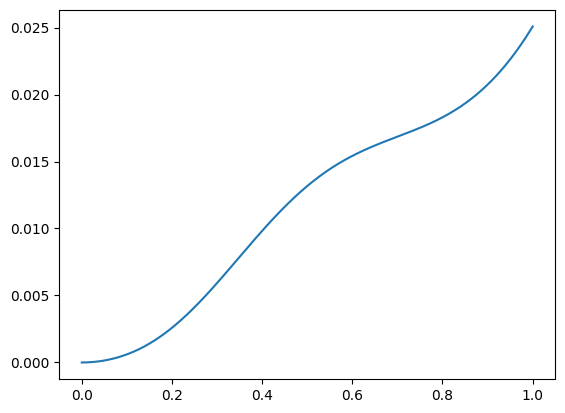

In [75]:
x = torch.linspace(0, 1, 10000).unsqueeze(0)
x = x.requires_grad_()
plt.plot(x.detach().squeeze(), f(x).detach().squeeze())

In [63]:
p

Parameter containing:
tensor([0.0580, 0.7259, 0.8806, 0.9271, 0.9458, 0.9554, 0.9615, 0.9658],
       requires_grad=True)

In [ ]:
def f(x):
    k = 8
    p = tensor([0.0580, 0.7259, 0.8806, 0.9271, 0.9458, 0.9554, 0.9615, 0.9658])
    powers = torch.arange(1, k+1)
    x_expanded = x.unsqueeze(-1)
    numerator_terms = p * x_expanded**(2 * powers)
    numerator = torch.sum(numerator_terms, dim=-1)
    denominator = (1 + x**2)**k
    return numerator / denominator

In [64]:
def fc(x):
    return x**2 / (x**2+1)

In [65]:
x = torch.linspace(0, 1, 10000).unsqueeze(0)
x = x.requires_grad_()
l = loss_fn(fc, x).mean()
print(l.item())

0.00018133393314201385


In [66]:
from sympy import symbols, summation, Eq, simplify, diff, Abs, S
from sympy.abc import x

i = symbols('i', integer=True)

numerator = summation(x**(2*i), (i, 1, k))
denominator = (1 + x**2)**k
f_s = numerator / denominator
print(f_s)

(x**16 + x**14 + x**12 + x**10 + x**8 + x**6 + x**4 + x**2)/(x**2 + 1)**8


In [67]:
f4 = diff(f_s, x, 4)
rhs = f_s**9

print(f4)
print(rhs)

24*(1820*x**12 + 1001*x**10 + 495*x**8 + 210*x**6 + 70*x**4 + 15*x**2 - 64*x**2*(140*x**12 + 91*x**10 + 55*x**8 + 30*x**6 + 14*x**4 + 5*x**2 + 1)/(x**2 + 1) - 96*x**2*(20*x**2/(x**2 + 1) - 3)*(8*x**14 + 7*x**12 + 6*x**10 + 5*x**8 + 4*x**6 + 3*x**4 + 2*x**2 + 1)/(x**2 + 1)**2 + 12*x**2*(440*x**4/(x**2 + 1)**2 - 120*x**2/(x**2 + 1) + 3)*(x**14 + x**12 + x**10 + x**8 + x**6 + x**4 + x**2 + 1)/(x**2 + 1)**2 + 1 + 8*(18*x**2/(x**2 + 1) - 1)*(120*x**14 + 91*x**12 + 66*x**10 + 45*x**8 + 28*x**6 + 15*x**4 + 6*x**2 + 1)/(x**2 + 1))/(x**2 + 1)**8
(x**16 + x**14 + x**12 + x**10 + x**8 + x**6 + x**4 + x**2)**9/(x**2 + 1)**72


In [68]:
difference = simplify(f4 - rhs)
print(difference)
difference == 0

(-x**18*(x**14 + x**12 + x**10 + x**8 + x**6 + x**4 + x**2 + 1)**9 + (x**2 + 1)**60*(x**2*(x**2 + 1)**3*(-215040*x**12 - 139776*x**10 - 84480*x**8 - 46080*x**6 - 21504*x**4 - 7680*x**2 - 1536) - 2304*x**2*(x**2 + 1)*(17*x**2 - 3)*(8*x**14 + 7*x**12 + 6*x**10 + 5*x**8 + 4*x**6 + 3*x**4 + 2*x**2 + 1) + 288*x**2*(440*x**4 + x**2*(-120*x**2 - 120) + 3*(x**2 + 1)**2)*(x**14 + x**12 + x**10 + x**8 + x**6 + x**4 + x**2 + 1) + (x**2 + 1)**4*(43680*x**12 + 24024*x**10 + 11880*x**8 + 5040*x**6 + 1680*x**4 + 360*x**2 + 24) + 192*(x**2 + 1)**2*(17*x**2 - 1)*(120*x**14 + 91*x**12 + 66*x**10 + 45*x**8 + 28*x**6 + 15*x**4 + 6*x**2 + 1)))/(x**2 + 1)**72


False